In [21]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Add parent directory to sys.path
sys.path.append(parent_dir)

print(parent_dir)


/home/adam/Documents/dev/gradual-aacbr/examples



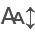

In [22]:
import torch
import torch.optim as optim
from itables import init_notebook_mode, show
import numpy as np
import matplotlib.pyplot as plt
import importlib

import ray
from ray import tune

import deeparguing.gradual_aacbr as gradual_aacbr
import deeparguing.semantics.relu_semantics as rs
import deeparguing.base_scores.feature_weighted_base_score as fwbs
import deeparguing.casebase_edge_weights.feature_weighted_partial_order as fwpo
import deeparguing.casebase_edge_weights.learned_partial_order as lpo
import deeparguing.base_scores.learned_base_score as lbs
import deeparguing.irrelevance_edge_weights.regular_irrelevance as ri
import deeparguing.feature_extractor.simple_cnn as simple_cnn
import deeparguing.feature_extractor.feature_weighted_extractor as fwe
import deeparguing.casebase_edge_weights.compute_partial_order as cpo

from deeparguing.regulariser import sparsity_regulariser, community_preservation_regulariser, connectivity_regulariser, feature_smoothness_regulariser, regularise
from deeparguing.train import static_train_model, evaluate_model, cluster_data
from deeparguing.tune import tune_model, objective

from helper import split_data, load_mnist

init_notebook_mode(all_interactive=True)

In [23]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(rs)
    importlib.reload(fwbs)
    importlib.reload(fwpo)
    importlib.reload(ri)
    importlib.reload(lpo)
    importlib.reload(lbs)
    importlib.reload(simple_cnn)
    importlib.reload(fwe)

reload_imports()

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Data Set

In [25]:
SEED = 42

In [26]:
# MNIST
X, y = load_mnist(device)
print(X.shape)
print(np.unique(y.cpu().numpy()))

torch.Size([1000, 28, 28])
[0. 1.]


In [27]:
def visualise(sample):
    sample = np.reshape(sample.detach().cpu().numpy(), (28, 28))
    plt.imshow(sample)
    plt.show()

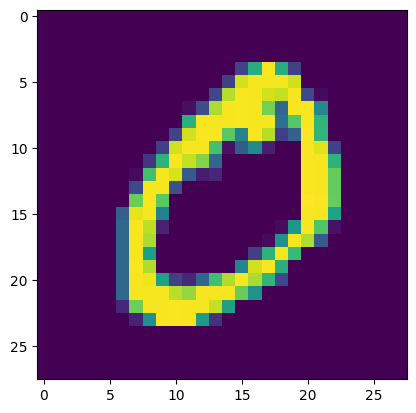

In [28]:

visualise(X[1])


In [29]:
show(y.cpu().numpy())
all_y = np.unique(y.cpu().numpy(), axis=0)

show(all_y)


## Train Model

### Split into Training, Validation and Test

In [30]:
train_full, train, val, test = split_data(X, y, SEED)

print(f"Test Size:  {len(test['X'])}")
print(f"Train Size:  {len(train['X'])}")
print(f"Validation Size:  {len(val['X'])}")

Test Size:  200
Train Size:  640
Validation Size:  160


### Cluster dataset

In [31]:
X_centroids, y_centroids = cluster_data(train["X"].cpu().numpy(), train["y"].cpu().numpy(), lambda _: 3)

3 clusters for [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
3 clusters for [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
3 clusters for [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
3 clusters for [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
3 clusters for [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
3 clusters for [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
3 clusters for [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
3 clusters for [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
3 clusters for [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
3 clusters for [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [32]:
# X_train = X_centroids
# y_train = y_centroids
X_centroids = torch.tensor(X_centroids, dtype=torch.float32).to(device)
y_centroids = torch.tensor(y_centroids, dtype=torch.float32).to(device)


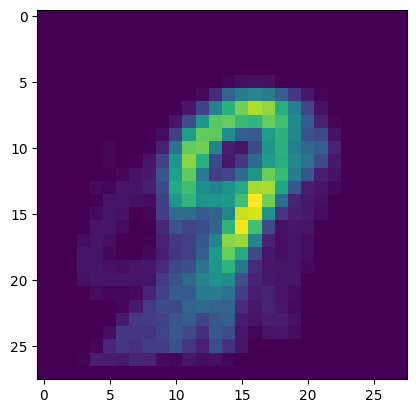

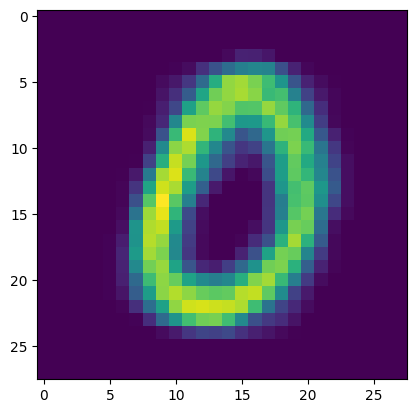

In [33]:
visualise(X_centroids[0])
visualise(X_centroids[-1])

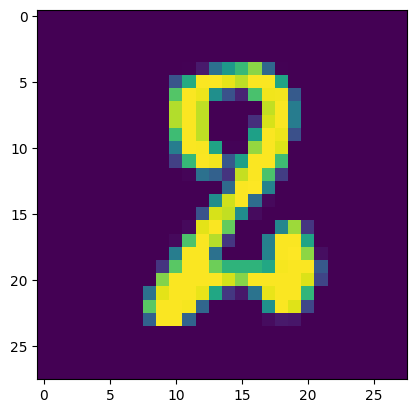

In [34]:
visualise(train["X"][0])

### Build AF

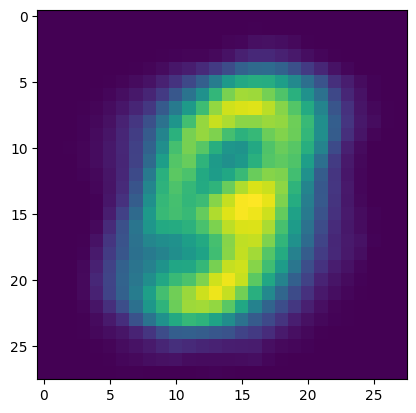

In [35]:

# Compare against the average for each column
means = train["X"].mean(axis=0)

visualise(means)

### Train Model

In [36]:
DEFAULT_CASE = means
# DEFAULT_CASE = torch.zeros_like(means)

X_DEFAULTS = DEFAULT_CASE.tile(len(all_y), 1, 1)
Y_DEFAULTS = torch.tensor(all_y).to(device)


In [37]:
MAX_ITERS = 20
EPOCHS = 500
USE_SYMMETRIC_ATTACKS = False
LR = 0.0003
MOMENTUM = 0.9
SHARPNESS = 0.1111 
TEMPERATURE = 0.5
TORCH_SEED = 695



In [38]:
reload_imports()
torch.manual_seed(TORCH_SEED) # TRY DIFFERENT INITIAL WEIGHTS 

# semantics = ms.MLPBasedSemantics(max_iters=MAX_ITERS, epsilon=0)
semantics = rs.ReluSemantics(max_iters=MAX_ITERS, epsilon=0)
cnn = simple_cnn.SimpleCNN().to(device)
feature_weights = fwe.FeatureWeightedExtractor(cnn.get_output_features()).to(device)
comp_func = cpo.Subtractor(temperature=TEMPERATURE, activation=torch.sigmoid)

partial_order = lpo.LearnedPartialOrder([cnn,feature_weights], comparison_func=comp_func).to(device)
irrelevance = ri.RegularIrrelevance(partial_order).to(device)

base_score = lbs.LearnedBaseScore([cnn,feature_weights]).to(device)


alpha = 5 * 1e-4


regulariser = lambda model: regularise(model, [
    [sparsity_regulariser, alpha], 
    [connectivity_regulariser, alpha], 
    [community_preservation_regulariser, alpha],
    # [feature_smoothness_regulariser, alpha]
    ])

model = gradual_aacbr.GradualAACBR(semantics, 
                                base_score,
                                irrelevance,
                                partial_order).to(device)


criterion = torch.nn.BCELoss()
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

Accuracy, Precision, Recall, F1
(0.125, np.float64(0.0486985236985237), np.float64(0.10574874686716791), np.float64(0.03822222222222223))


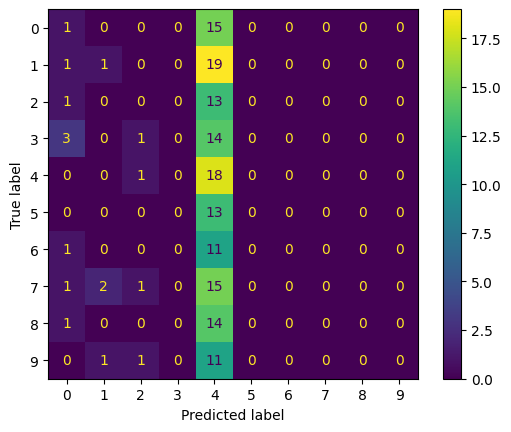

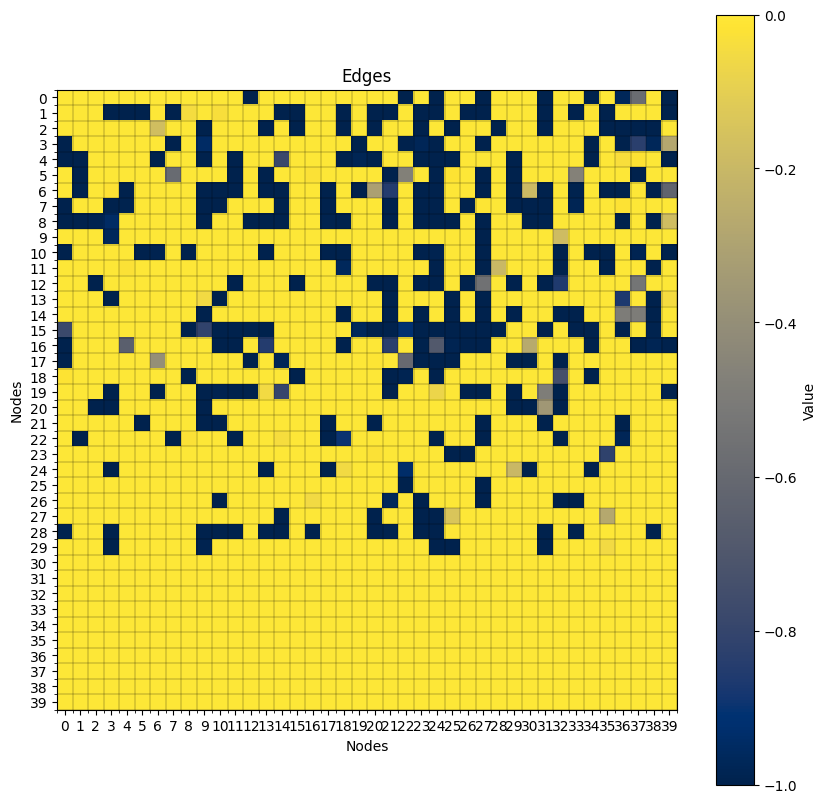

CNN PARAMETERS ARE NOT PRINTED


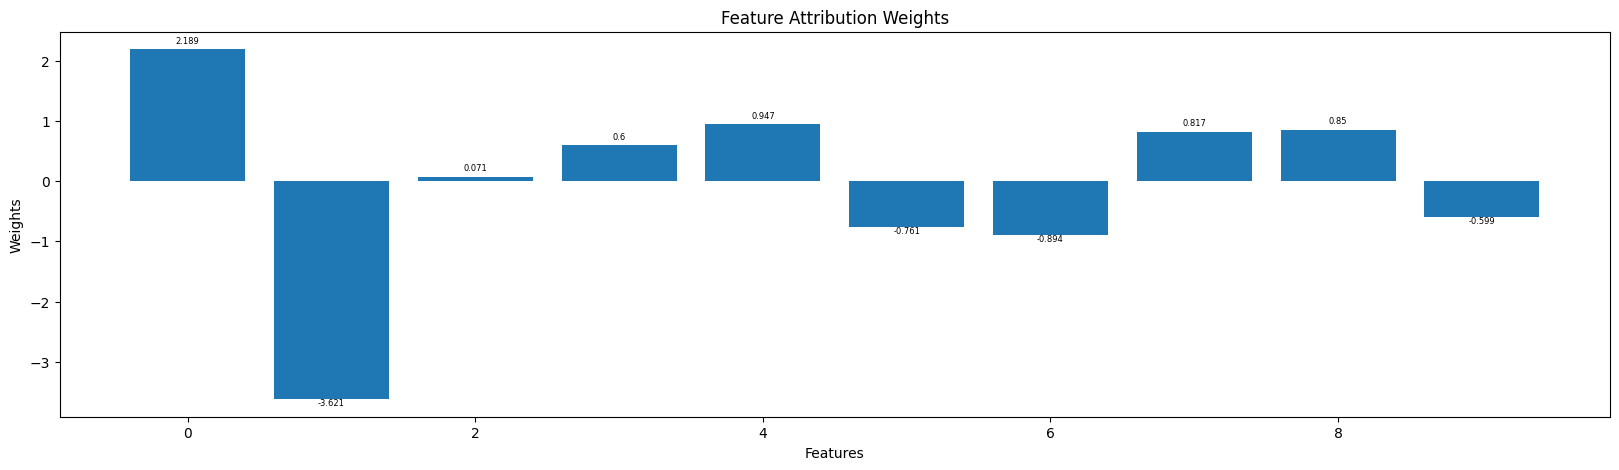

CNN PARAMETERS ARE NOT PRINTED


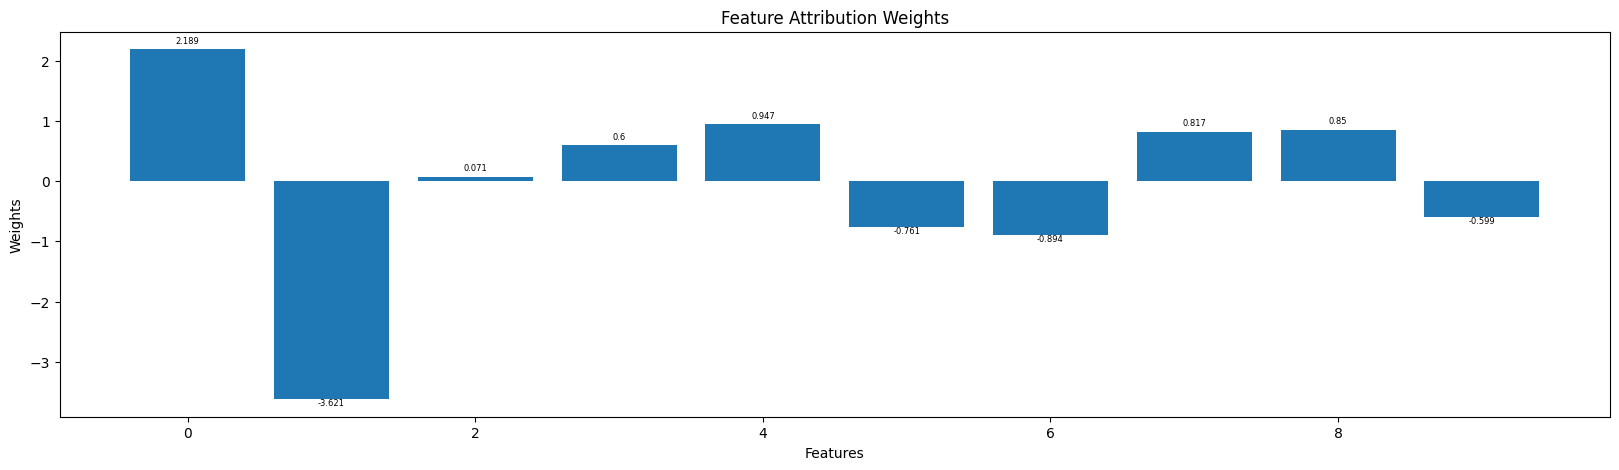

In [39]:
reload_imports()
evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, val["X"], val["y"], use_blockers=False, show_confusion=True,  print_matrix=True, print_compute_graph=True, print_graph = False )
model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

Epoch 500, Loss: 2.443637: 100%|██████████| 500/500 [02:10<00:00,  3.84it/s]


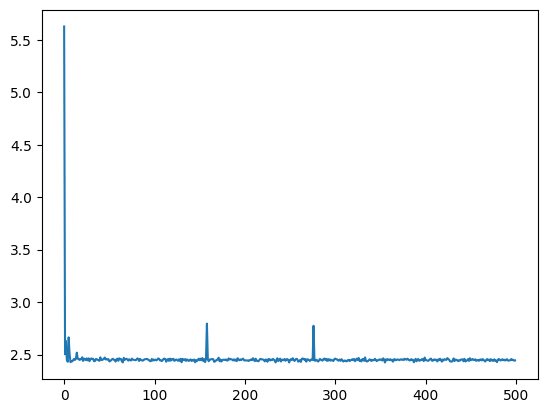

In [40]:
static_train_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, optimizer, 
                   criterion, EPOCHS, X_new_cases=train["X"], y_new_cases=train["y"],   
                   use_symmetric_attacks=False, use_blockers=False, plot_loss_curve=True,
                   regularise_graph=regulariser)

Accuracy, Precision, Recall, F1
(0.1, np.float64(0.01), np.float64(0.1), np.float64(0.01818181818181818))


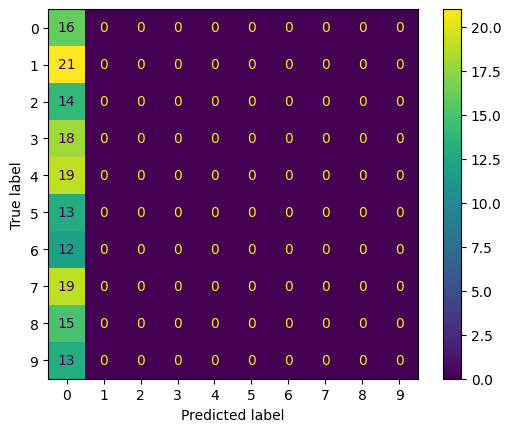

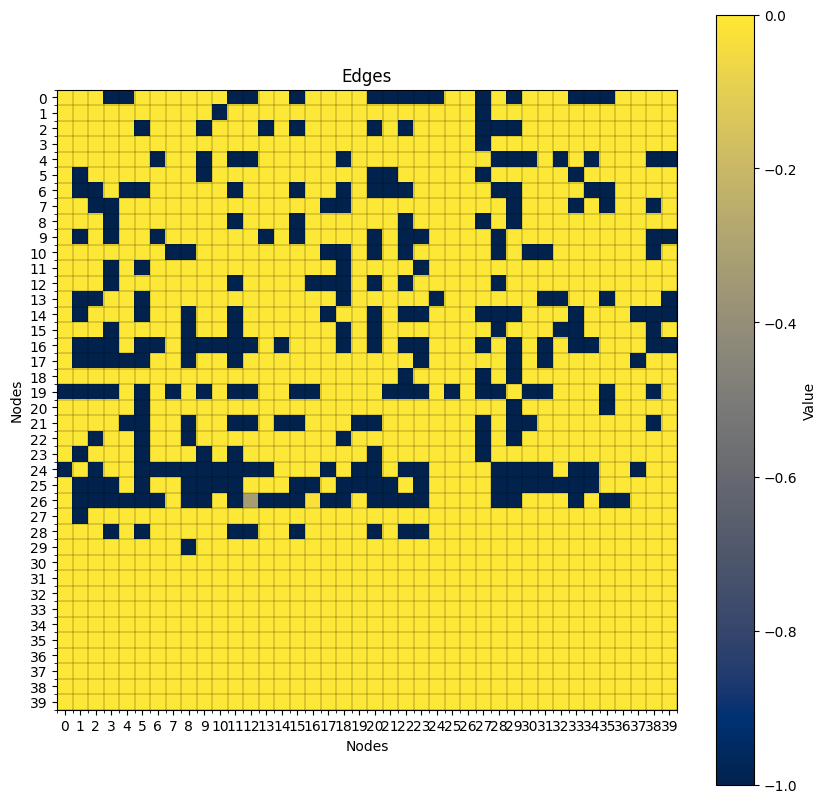

CNN PARAMETERS ARE NOT PRINTED


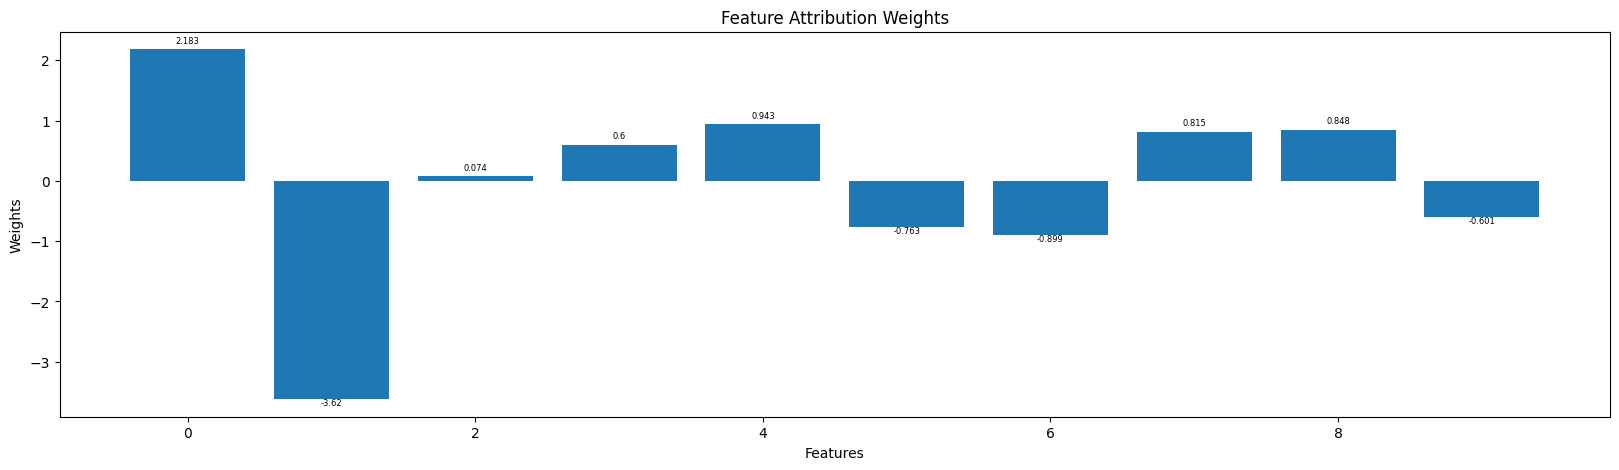

CNN PARAMETERS ARE NOT PRINTED


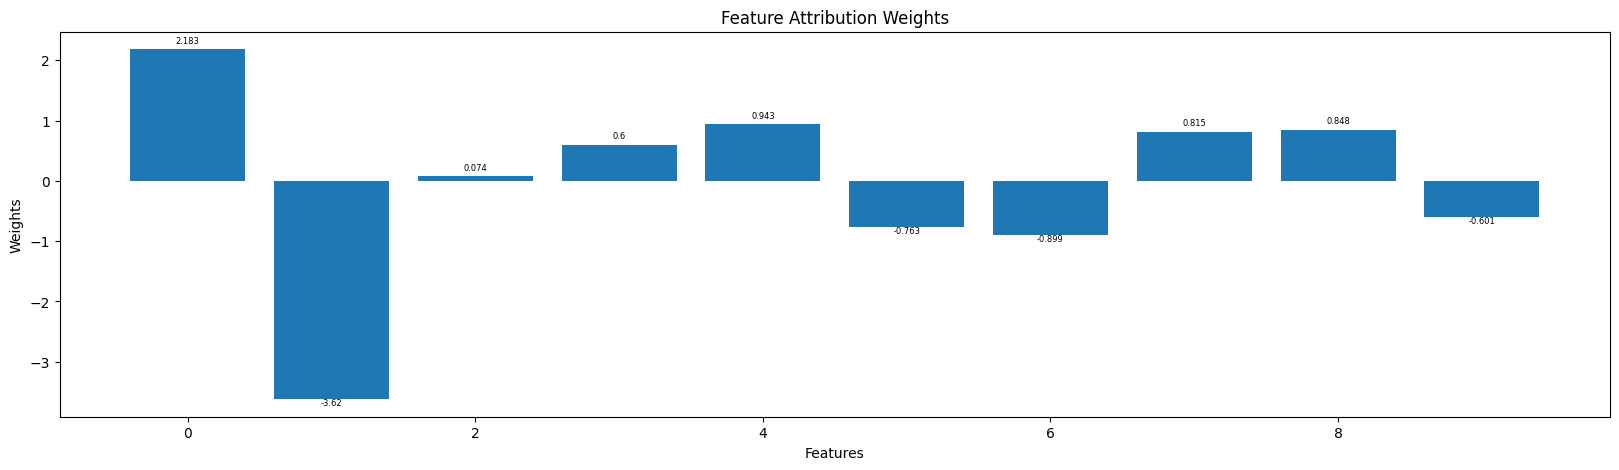

In [41]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, val["X"], val["y"], use_blockers=False, show_confusion=True,  print_matrix=True, print_compute_graph=True, print_graph = False )

model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

In [42]:
assert(False)

AssertionError: 